# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [12]:
# untuk plot Q-Q
import scipy.stats as stats

In [13]:
df_california = pd.read_csv('california_dataset.csv')

In [14]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

=== Visualisasi Kolom: MedInc ===


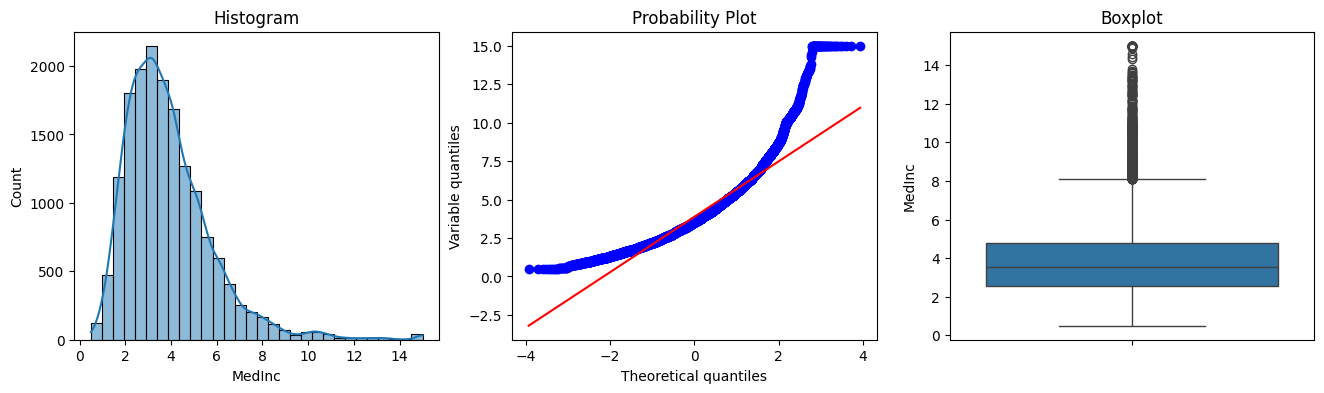

=== Visualisasi Kolom: HouseAge ===


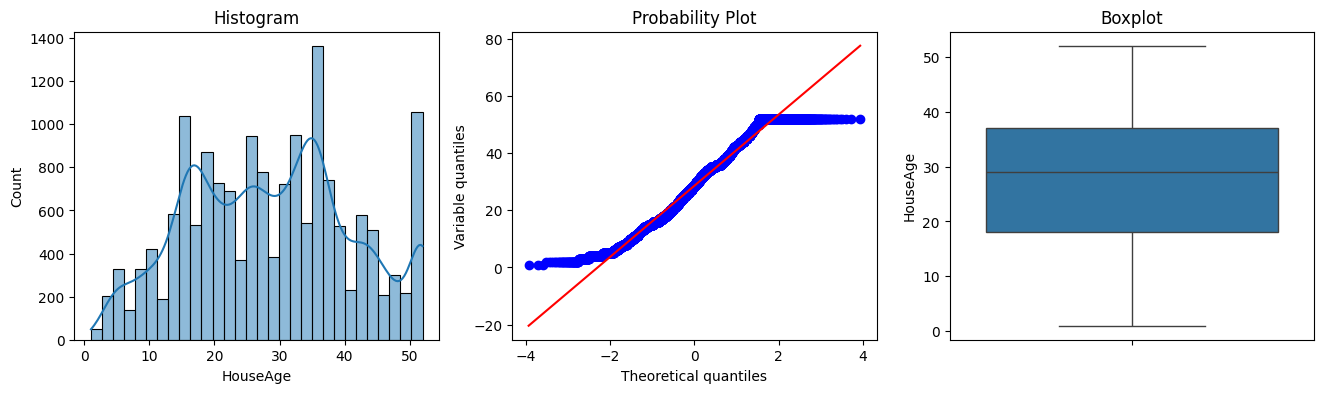

=== Visualisasi Kolom: AveRooms ===


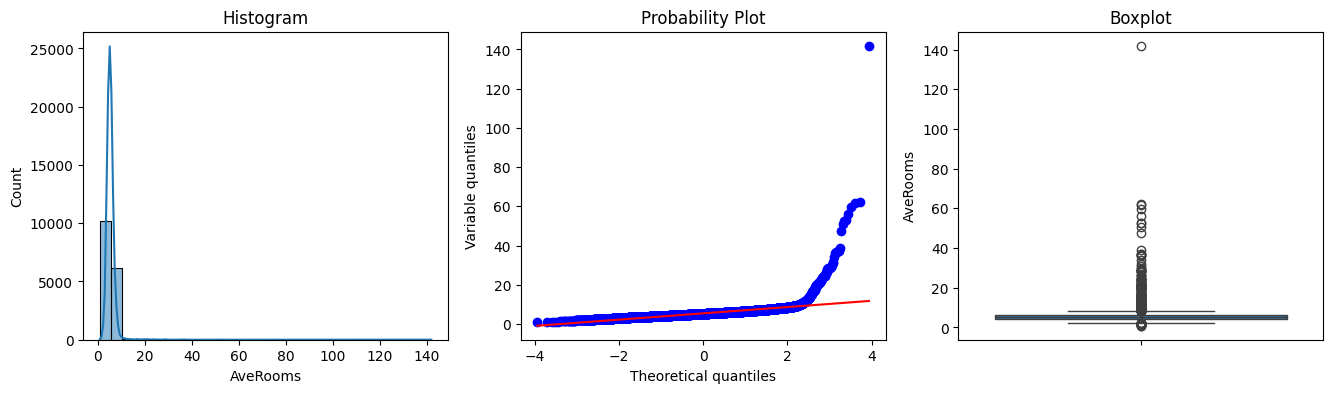

=== Visualisasi Kolom: AveBedrms ===


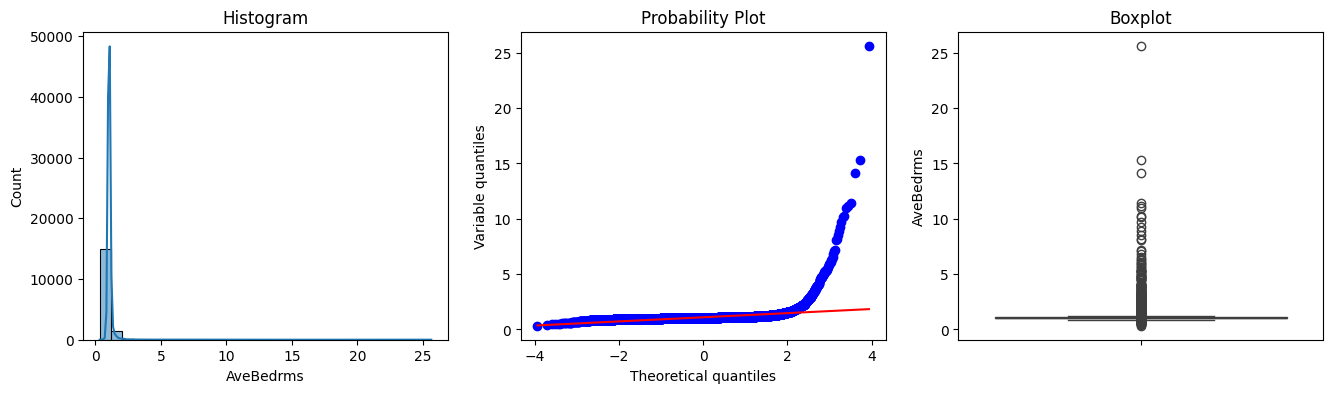

=== Visualisasi Kolom: AveOccup ===


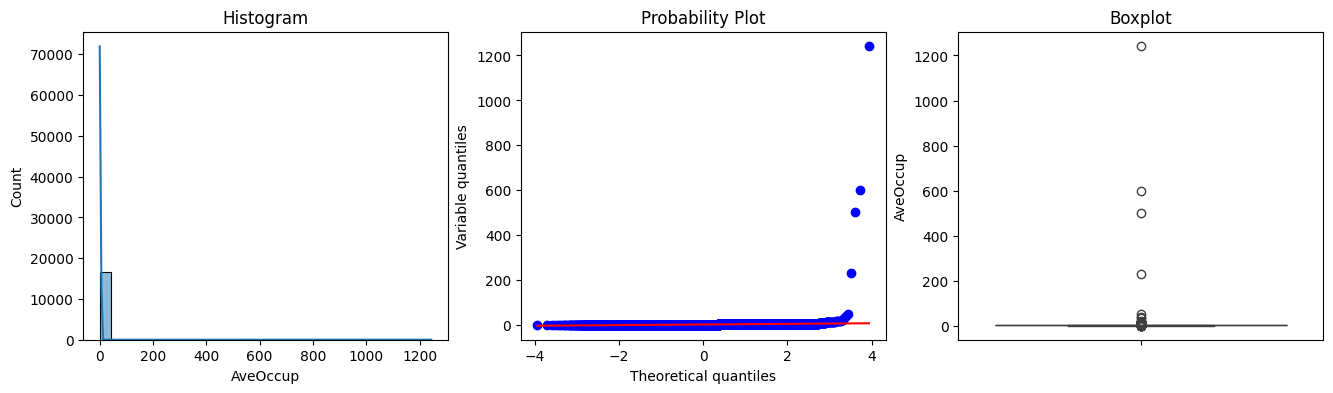

In [15]:
import scipy.stats as stats

# Fungsi untuk plot (diambil dari referensi materi)
def check_plot(df, variable):
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30, kde=True)
    plt.title('Histogram')
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')
    plt.show()

# Daftar kolom yang diminta
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Split data 80:20 (sesuai aturan materi, sebelum dihandling)
train_cal, test_cal = train_test_split(df_california, test_size=0.2, random_state=42)

# Looping untuk melihat distribusi dan outlier
for col in kolom_kolom:
    print(f"=== Visualisasi Kolom: {col} ===")
    check_plot(train_cal, col)

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

Distribusi 'MedInc' SETELAH di-handling dengan IQR:


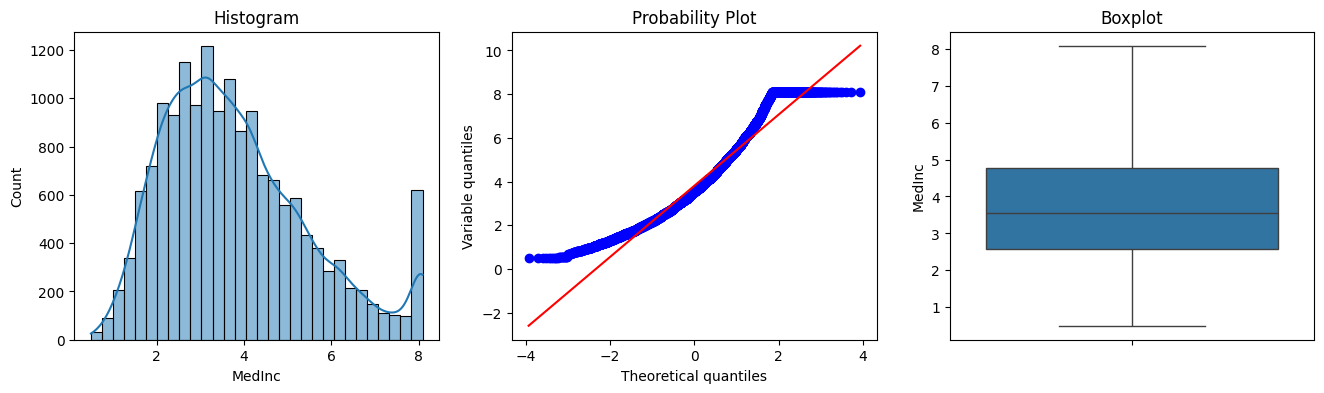

In [16]:
# Fungsi untuk mencari batas IQR
def find_outlier_boundary(df, variable):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)
    return upper_boundary, lower_boundary

# Menentukan batas atas dan bawah untuk MedInc pada data train
upper_limit, lower_limit = find_outlier_boundary(train_cal, 'MedInc')

# Replace outlier dengan batas atas/bawah (Capping)
train_cal['MedInc'] = np.where(
    train_cal['MedInc'] > upper_limit, upper_limit,
    np.where(train_cal['MedInc'] < lower_limit, lower_limit, train_cal['MedInc'])
)

# Cek kembali distribusinya setelah di-handling
print("Distribusi 'MedInc' SETELAH di-handling dengan IQR:")
check_plot(train_cal, 'MedInc')

In [17]:
# Melakukan loop untuk mengecek distribusi tiap kolom


# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [18]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [19]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [20]:
# 1. Cek persentase missing value di kolom Headquarters (biasanya ditandai '-1' atau 'Unknown')
missing_hq = len(df_company[df_company['Headquarters'].isin(['-1', 'Unknown'])])
persentase_missing = (missing_hq / len(df_company)) * 100

print(f"1. Persentase missing value Headquarters: {persentase_missing:.2f}%")

# 2 & 3. Syarat drop atau handling
if persentase_missing > 20:
    print("2. Keputusan: Drop kolom Headquarters karena missing value > 20%")
    # df_company = df_company.drop(columns=['Headquarters'])
else:
    print("2. Keputusan: Tidak di-drop (kurang dari 20%).")
    print("3. Handling: Karena 'Headquarters' adalah data kategorikal/teks, kita gunakan MODUS.")
    
    # Split data sebelum handling
    train_comp, test_comp = train_test_split(df_company, test_size=0.2, random_state=42)
    
    # Cari modus dari data train (abaikan nilai '-1' dan 'Unknown')
    modus_hq = train_comp[~train_comp['Headquarters'].isin(['-1', 'Unknown'])]['Headquarters'].mode()[0]
    
    # Lakukan imputasi dengan modus ke data train dan test
    train_comp['Headquarters'] = train_comp['Headquarters'].replace(['-1', 'Unknown'], modus_hq)
    test_comp['Headquarters'] = test_comp['Headquarters'].replace(['-1', 'Unknown'], modus_hq)
    
    print(f"   => Handling selesai. Nilai missing diganti dengan modus: {modus_hq}")


1. Persentase missing value Headquarters: 4.61%
2. Keputusan: Tidak di-drop (kurang dari 20%).
3. Handling: Karena 'Headquarters' adalah data kategorikal/teks, kita gunakan MODUS.
   => Handling selesai. Nilai missing diganti dengan modus: New York, NY


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [22]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [23]:
#Splitting terlebih dahulu


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [24]:
from sklearn.preprocessing import LabelEncoder

kolom_encode = [
    'StreamingMovies', 'StreamingTV', 'TechSupport', 
    'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines'
]

# 1 & 2. Ganti nilai yang tidak sesuai dan validasi
for col in kolom_encode:
    # Menggabungkan 'No internet service' dan 'No phone service' menjadi 'No'
    df_churn[col] = df_churn[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    print(f"Validasi {col}:\n{df_churn[col].value_counts()}\n")

# Split data terlebih dahulu
train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)

# 3. Lakukan Label Encoder
le = LabelEncoder()

# Fit dan Transform di data train, lalu Transform di data test
for col in kolom_encode:
    train_churn[col] = le.fit_transform(train_churn[col])
    test_churn[col] = le.transform(test_churn[col])

print("Tampilan sebagian data Train setelah Label Encoding (0 = No, 1 = Yes):")
display(train_churn[kolom_encode].head())


Validasi StreamingMovies:
No     4311
Yes    2732
Name: StreamingMovies, dtype: int64

Validasi StreamingTV:
No     4336
Yes    2707
Name: StreamingTV, dtype: int64

Validasi TechSupport:
No     4999
Yes    2044
Name: TechSupport, dtype: int64

Validasi DeviceProtection:
No     4621
Yes    2422
Name: DeviceProtection, dtype: int64

Validasi OnlineBackup:
No     4614
Yes    2429
Name: OnlineBackup, dtype: int64

Validasi OnlineSecurity:
No     5024
Yes    2019
Name: OnlineSecurity, dtype: int64

Validasi MultipleLines:
No     4072
Yes    2971
Name: MultipleLines, dtype: int64

Tampilan sebagian data Train setelah Label Encoding (0 = No, 1 = Yes):


,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,1,0,0,1,0,1,0
1623,1,1,0,0,1,0,1
6074,0,0,0,0,0,0,0
1362,0,0,0,0,0,0,0
6754,0,0,1,0,1,1,1


## Selesai :)